# FLOODISI — Flood Detection Integrating Spectral Indices

Any reference to the code and the work can be made by citing:

Bazzan, T.; Renno, C. D.; Reckziegel, E. W., Guasselli, L. A. FLOODISI: Flood Detection Integrating Spectral Indices - a tool for open water mapping. 2026

# For more information, contact:

Thiago Bazzan, E-mail: tbazzan@gmail.com

## Step 1 - Import

In [17]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

## Step 2 - Specify the file paths



In [18]:

# Ajuste o caminho da imagem de entrada

input_raster = "/content/20240508_l8_bands_aoi_bhsinos_reflectancia.tif"

# Diretório de saída

output_dir = Path("/content/floodisi_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print("Input raster:", input_raster)
print("Output dir:", output_dir)

Input raster: /content/20240508_l8_bands_aoi_bhsinos_reflectancia.tif
Output dir: /content/floodisi_outputs


## Step 3 - Load raster multiband

In [19]:
# Load

with rasterio.open(input_raster) as src:
    image = src.read().astype("float32")
    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

print("Shape:", image.shape)
print("CRS:", crs)
print("Transform:", transform)
print("Nodata:", nodata)

# Landsat-8/OLI or Landsat-9/OLI-2:

# Upcoming bands: coastal, blue, green, red, nir, swir1, swir2

if image.shape[0] < 7:
    raise ValueError("The image must contain at least 7 bands: coastal, blue, green, red, nir, swir1, swir2.")

coastal, blue, green, red, nir, swir1, swir2 = image[:7]

bands = {
    "coastal": coastal,
    "blue": blue,
    "green": green,
    "red": red,
    "nir": nir,
    "swir1": swir1,
    "swir2": swir2
}

Shape: (7, 400, 600)
CRS: EPSG:32722
Transform: | 30.00, 0.00, 482580.00|
| 0.00,-30.00, 6717300.00|
| 0.00, 0.00, 1.00|
Nodata: -3.3999999521443642e+38


## Step 4 - Thresholds and Noise Filters

In [4]:
thresholds = {
    "ndwi": 0.012,
    "mndwi1": 0.109,
    "mndwi2": 0.231,
    "mndwi3": 0.055,
    "wri": 0.979,
    "ndfi1": 0.094,
    "ndfi2": 0.276,
    "aweish": -0.132,
    "aweinsh": -0.092,
    "wi2015": 1.515,
    "mbwi": -0.124
}

noise_filters = {
    "sum567_ndwi": 0.373,
    "sum567_mndwi1": 0.369,
    "sum567_mndwi2": 0.353,
    "sum567_mndwi3": 0.373,
    "sum567_wri": 0.373,
    "sum567_ndfi1": 0.369,
    "sum567_ndfi2": 0.369,
    "red_aweish": 0.039,
    "red_aweinsh": 0.039,
    "sum567_wi2015": 0.373,
    "red_mbwi": 0.039
}

pd.DataFrame({
    "index": list(thresholds.keys()),
    "threshold": list(thresholds.values())
})

,index,threshold
0,ndwi,0.012
1,mndwi1,0.109
2,mndwi2,0.231
3,mndwi3,0.055
4,wri,0.979
5,ndfi1,0.094
6,ndfi2,0.276
7,aweish,-0.132
8,aweinsh,-0.092
9,wi2015,1.515


## Step 5. Auxiliary functions

In [5]:
def safe_divide(numerator, denominator):
    # Divisão segura para evitar inf e divisão por zero.
    # Retorna NaN quando o denominador é zero.
    with np.errstate(divide="ignore", invalid="ignore"):
        result = np.where(denominator != 0, numerator / denominator, np.nan)
    return result.astype("float32")


def threshold_water(index_array, threshold):
    # Equivalente à matriz de reclassificação:
    # -Inf até threshold = 0
    # threshold até Inf = 1
    return np.where(index_array <= threshold, 0, 1).astype("uint8")


def threshold_sum567(sum567_array, threshold):
    # Filtro sum567:
    # -Inf até threshold = 0
    # threshold até Inf = 1
    return np.where(sum567_array <= threshold, 0, 1).astype("uint8")


def threshold_red_inverse(red_array, threshold):
    # Filtro pela banda red usado em AWEIsh, AWEInsh e MBWI:
    # -Inf até threshold = 1
    # threshold até Inf = 0
    return np.where(red_array <= threshold, 1, 0).astype("uint8")


def reclass_positive(binary_difference):
    # Reclassificação final:
    # -Inf até 0 = 0
    # 0 até Inf = 1
    return np.where(binary_difference <= 0, 0, 1).astype("uint8")


def write_geotiff(array, output_path, reference_profile, dtype=None, nodata_value=None):
    # Exporta array 2D como GeoTIFF usando o profile do raster de referência.
    output_profile = reference_profile.copy()

    if dtype is None:
        dtype = array.dtype

    output_profile.update(
        count=1,
        dtype=dtype,
        compress="lzw"
    )

    if nodata_value is not None:
        output_profile.update(nodata=nodata_value)

    with rasterio.open(output_path, "w", **output_profile) as dst:
        dst.write(array.astype(dtype), 1)


def plot_raster(array, title, cmap="Blues", legend=True, figsize=(8, 8)):
    # Plot simples para visualização em notebook.
    plt.figure(figsize=figsize)
    img = plt.imshow(array, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    if legend:
        plt.colorbar(img, fraction=0.035, pad=0.04)
    plt.show()


def calculate_area_km2(binary_map, reference_profile):
    # Calcula área da classe 1 em km².
    # Assume raster projetado em metros.
    transform = reference_profile["transform"]
    pixel_area_m2 = abs(transform.a * transform.e)
    area_km2 = np.sum(binary_map == 1) * pixel_area_m2 / 1e6
    return area_km2


def apply_sum567_filter(water_map, nir, swir1, swir2, filter_threshold):
    # Aplica filtro sum567 e retorna mapa corrigido.
    sum567_index = nir + swir1 + swir2
    noise_map = threshold_sum567(sum567_index, filter_threshold)
    filtered = water_map.astype("int16") - noise_map.astype("int16")
    corrected = reclass_positive(filtered)
    return corrected


def apply_red_filter(water_map, red, filter_threshold):
    # Aplica filtro red inverso e retorna mapa corrigido.
    red_noise_map = threshold_red_inverse(red, filter_threshold)
    filtered = water_map.astype("int16") - red_noise_map.astype("int16")
    corrected = reclass_positive(filtered)
    return corrected

## Step 6. Calculation of spectral indices for water

- NDWI, MNDWI-1, MNDWI-2, MNDWI-3, WRI, NDFI-1, NDFI-2, AWEIsh, AWEInsh, WI2015, MBWI

In [6]:
indices = {}

indices["ndwi"] = safe_divide(green - nir, green + nir)
indices["mndwi1"] = safe_divide(green - swir1, green + swir1)
indices["mndwi2"] = safe_divide(green - swir2, green + swir2)
indices["mndwi3"] = safe_divide(red - nir, red + nir)

indices["wri"] = safe_divide(green + red, nir + swir1)

indices["ndfi1"] = safe_divide(red - swir1, red + swir1)
indices["ndfi2"] = safe_divide(red - swir2, red + swir2)

indices["aweish"] = (
    blue + 0.25 * green - 1.5 * (nir + swir1) - 0.25 * swir2
).astype("float32")

indices["aweinsh"] = (
    4 * (green - swir1) - (0.25 * nir + 2.75 * swir2)
).astype("float32")

indices["wi2015"] = (
    1.7204 + 171 * green + 3 * red - 70 * nir - 45 * swir1 - 71 * swir2
).astype("float32")

indices["mbwi"] = (
    2 * green - red - nir - swir1 - swir2
).astype("float32")

print("Índices calculados:", list(indices.keys()))

Índices calculados: ['ndwi', 'mndwi1', 'mndwi2', 'mndwi3', 'wri', 'ndfi1', 'ndfi2', 'aweish', 'aweinsh', 'wi2015', 'mbwi']


In [ ]:
# Visualizar um índice de exemplo
plot_raster(indices["ndwi"], "NDWI Index", cmap="viridis", legend=True)

## 6. Limiarização, filtragem e exportação dos mapas individuais

A rotina abaixo:

1. Classifica o índice em água/não água.
2. Exporta o índice contínuo.
3. Exporta o mapa binário antes do filtro.
4. Aplica o filtro correspondente.
5. Exporta o mapa corrigido.

In [7]:
# ============================================================
# THRESHOLD, FILTER AND EXPORT EACH INDEX
# ============================================================

filter_config = {
    "ndwi": ("sum567", noise_filters["sum567_ndwi"]),
    "mndwi1": ("sum567", noise_filters["sum567_mndwi1"]),
    "mndwi2": ("sum567", noise_filters["sum567_mndwi2"]),
    "mndwi3": ("sum567", noise_filters["sum567_mndwi3"]),
    "wri": ("sum567", noise_filters["sum567_wri"]),
    "ndfi1": ("sum567", noise_filters["sum567_ndfi1"]),
    "ndfi2": ("sum567", noise_filters["sum567_ndfi2"]),
    "aweish": ("red", noise_filters["red_aweish"]),
    "aweinsh": ("red", noise_filters["red_aweinsh"]),
    "wi2015": ("sum567", noise_filters["sum567_wi2015"]),
    "mbwi": ("red", noise_filters["red_mbwi"])
}

water_maps = {}
water_maps_corrected = {}

for index_name, index_array in indices.items():
    print(f"Processing {index_name.upper()}...")

    # Export continuous index
    index_out = output_dir / f"{index_name}_index.tif"
    write_geotiff(index_array, index_out, profile, dtype="float32", nodata_value=np.nan)

    # Threshold water map
    water_map = threshold_water(index_array, thresholds[index_name])
    water_maps[index_name] = water_map

    water_map_out = output_dir / f"{index_name}_water_map.tif"
    write_geotiff(water_map, water_map_out, profile, dtype="uint8", nodata_value=0)

    # Apply filter
    filter_type, filter_threshold = filter_config[index_name]

    if filter_type == "sum567":
        corrected = apply_sum567_filter(water_map, nir, swir1, swir2, filter_threshold)
    elif filter_type == "red":
        corrected = apply_red_filter(water_map, red, filter_threshold)
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")

    water_maps_corrected[index_name] = corrected

    corrected_out = output_dir / f"{index_name}_water_map_corrected.tif"
    write_geotiff(corrected, corrected_out, profile, dtype="uint8", nodata_value=0)

print("Processamento concluído.")

Processing NDWI...
Processing MNDWI1...
Processing MNDWI2...
Processing MNDWI3...


Processing WRI...
Processing NDFI1...
Processing NDFI2...
Processing AWEISH...


Processing AWEINSH...
Processing WI2015...
Processing MBWI...
Processamento concluído.


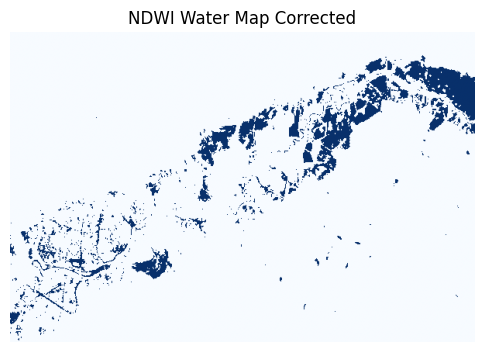

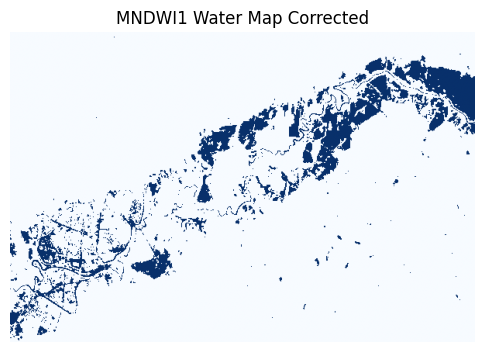

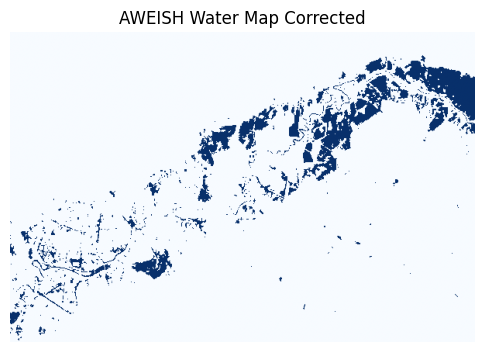

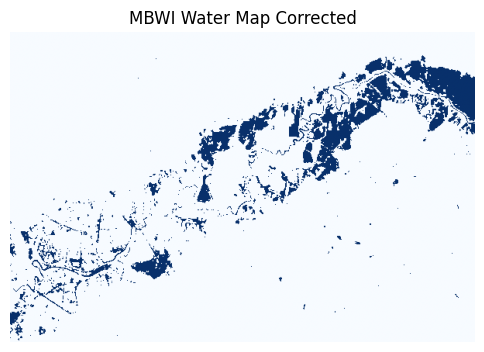

In [8]:
# Visualizar alguns mapas corrigidos

for name in ["ndwi", "mndwi1", "aweish", "mbwi"]:
    plot_raster(
        water_maps_corrected[name],
        f"{name.upper()} Water Map Corrected",
        cmap="Blues",
        legend=False,
        figsize=(6, 6)
    )

## 7. Integração dos mapas — Water Frequency Map e Integrated Water Map

O **Water Frequency Map** representa quantos índices classificaram cada pixel como água.

O **Integrated Water Map (IWM)** classifica como água todo pixel com frequência maior que zero.

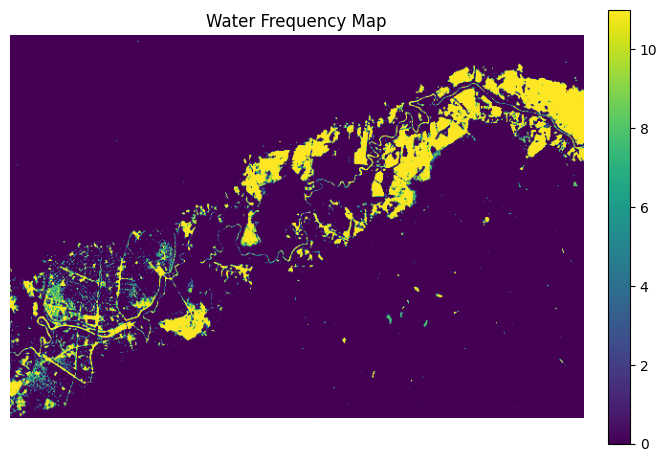

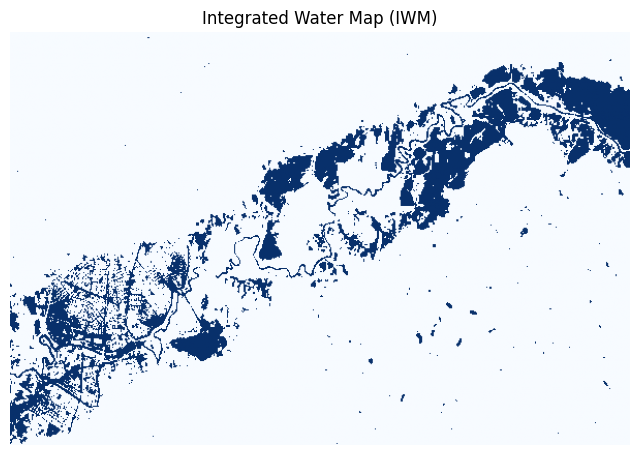

In [9]:
# ============================================================
# STEP 5 - INTEGRATE WATER MAPS
# ============================================================

index_order = [
    "ndwi", "mndwi1", "mndwi2", "mndwi3",
    "wri", "ndfi1", "ndfi2",
    "aweish", "aweinsh", "wi2015", "mbwi"
]

water_frequency_map = np.zeros_like(water_maps_corrected[index_order[0]], dtype="uint8")

for name in index_order:
    water_frequency_map += water_maps_corrected[name].astype("uint8")

integrated_water_map = reclass_positive(water_frequency_map)

write_geotiff(
    water_frequency_map,
    output_dir / "water_frequency_map.tif",
    profile,
    dtype="uint8",
    nodata_value=0
)

write_geotiff(
    integrated_water_map,
    output_dir / "integrated_water_map.tif",
    profile,
    dtype="uint8",
    nodata_value=0
)

plot_raster(water_frequency_map, "Water Frequency Map", cmap="viridis", legend=True)
plot_raster(integrated_water_map, "Integrated Water Map (IWM)", cmap="Blues", legend=False)

## 8. Cálculo de área da classe água

O cálculo considera a classe `1` como água.

> Atenção: a área em km² assume que o raster está em sistema projetado com unidade em metros, por exemplo UTM.  
> Se o raster estiver em coordenadas geográficas (`EPSG:4326`), reprojete antes de calcular área.

In [10]:
# ============================================================
# STEP 6 - CALCULATE WATER AREA
# ============================================================

display_names = {
    "ndwi": "NDWI",
    "mndwi1": "MNDWI-1",
    "mndwi2": "MNDWI-2",
    "mndwi3": "MNDWI-3",
    "wri": "WRI",
    "ndfi1": "NDFI-1",
    "ndfi2": "NDFI-2",
    "aweish": "AWEIsh",
    "aweinsh": "AWEInsh",
    "wi2015": "WI2015",
    "mbwi": "MBWI"
}

area_records = []

for name in index_order:
    area_km2 = calculate_area_km2(water_maps_corrected[name], profile)
    area_records.append({
        "name": display_names[name],
        "area_km2": area_km2
    })

area_records.append({
    "name": "IWM",
    "area_km2": calculate_area_km2(integrated_water_map, profile)
})

area_df = pd.DataFrame(area_records).sort_values("area_km2", ascending=False)
area_df

,name,area_km2
11,IWM,26.5599
6,NDFI-2,25.2117
5,NDFI-1,23.2479
2,MNDWI-2,23.1993
4,WRI,21.0393
8,AWEInsh,20.0286
9,WI2015,20.0178
1,MNDWI-1,19.2114
3,MNDWI-3,18.2664
10,MBWI,17.0577


In [11]:
# Exportar tabela de áreas

area_csv = output_dir / "water_area_km2.csv"
area_df.to_csv(area_csv, index=False)

print("Tabela exportada:", area_csv)

Tabela exportada: /content/floodisi_outputs/water_area_km2.csv


## 9. Gráfico de área por índice

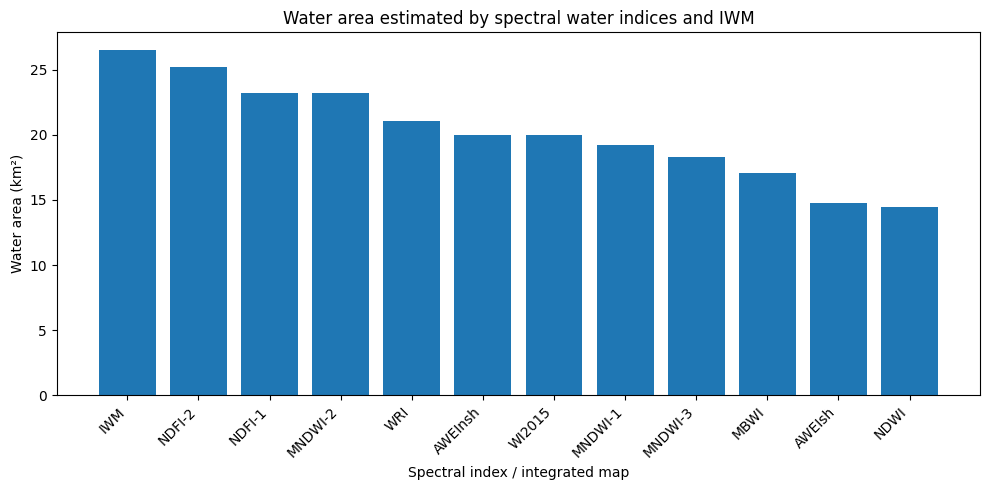

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(area_df["name"], area_df["area_km2"])
plt.ylabel("Water area (km²)")
plt.xlabel("Spectral index / integrated map")
plt.title("Water area estimated by spectral water indices and IWM")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Verificação dos arquivos exportados

In [13]:
# Listar arquivos exportados

for file in sorted(output_dir.glob("*")):
    print(file)

/content/floodisi_outputs/aweinsh_index.tif
/content/floodisi_outputs/aweinsh_water_map.tif
/content/floodisi_outputs/aweinsh_water_map_corrected.tif
/content/floodisi_outputs/aweish_index.tif
/content/floodisi_outputs/aweish_water_map.tif
/content/floodisi_outputs/aweish_water_map_corrected.tif
/content/floodisi_outputs/integrated_water_map.tif
/content/floodisi_outputs/mbwi_index.tif
/content/floodisi_outputs/mbwi_water_map.tif
/content/floodisi_outputs/mbwi_water_map_corrected.tif
/content/floodisi_outputs/mndwi1_index.tif
/content/floodisi_outputs/mndwi1_water_map.tif
/content/floodisi_outputs/mndwi1_water_map_corrected.tif
/content/floodisi_outputs/mndwi2_index.tif
/content/floodisi_outputs/mndwi2_water_map.tif
/content/floodisi_outputs/mndwi2_water_map_corrected.tif
/content/floodisi_outputs/mndwi3_index.tif
/content/floodisi_outputs/mndwi3_water_map.tif
/content/floodisi_outputs/mndwi3_water_map_corrected.tif
/content/floodisi_outputs/ndfi1_index.tif
/content/floodisi_outputs/nd

## 11. Referências principais

- McFeeters, S. K. (1996). The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features.
- Xu, H. (2006). Modification of NDWI to enhance open water features in remotely sensed imagery.
- Boschetti et al. (2014). Comparative Analysis of Normalised Difference Spectral Indices.
- Feyisa et al. (2014). Automated Water Extraction Index.
- Fisher et al. (2016). Comparing Landsat water index methods.
- Wang et al. (2018). Multi-Band Water Index.